# Energy Confinement Time Scaling for Negative-Triangularity Plasmas

An IPB98(y,2)-style engineering scaling of the thermal energy confinement
time $\tau_{E,th}$ for the stationary negative-triangularity (NT) phases of
Paz-Soldan *et al.*, Nucl. Fusion **64** 094002 (2024), [doi:10.1088/1741-4326/ad69a4](https://doi.org/10.1088/1741-4326/ad69a4)
(`data/nt_scaling_shotlist.csv`), built on the `scripts/` package of this
repository.

Method in three lines:

1. **Model** — $\ln\tau = \ln C + 0.19\ln M + \sum_i \alpha_i \ln x_i$ with free
   exponents for $I_p$, $B_t$, $\langle n_e\rangle$, $P_{tot}$ and geometry
   ($R_0$, $\kappa_a$, $\epsilon$) frozen at the IPB98(y,2) values — a
   single-device database cannot constrain size scaling.
2. **Weighting** — a Gaussian KDE over the four free regressors down-weights
   densely sampled regions of parameter space (free regressors only, density
   floored at its 5th percentile, effective sample size reported).
3. **Uncertainty** — refits on random 75% / 50% subsets, 1000 repeats each,
   exponents presented as distributions.

| Section | Content |
|---|---|
| 1 | Load, unit conversion, quality filter |
| 2 | Fit sample ($f_{GW} < 1$) |
| 3 | Sampling of parameter space (what the KDE weighting corrects for) |
| 4 | KDE-weighted fit (headline) |
| 5 | OLS fit (weighting sensitivity) |
| 6 | Bootstrap exponent distributions |
| 7 | Summary |

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # repo root, so `scripts` imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scripts import (
    load_nt_shotlist, fit_power_law, subset_bootstrap,
    ENGINEERING_REGRESSORS, FREE_REGRESSORS, EXPONENT_LABELS,
    FIXED_GEOMETRY_EXPONENTS, ISOTOPE_EXPONENT_THERMAL, IPB98Y2, plotting)

SEED = 2023
N_REPEATS = 1000
FRACS = (0.75, 0.50)
TARGET = 'ln_tauth_ptot'
ID_COLUMNS = ['tok', 'shotnum', 'tstart', 'tend']
TAU_LABELS = (r'Predicted $\tau_{E,th}$ [s]', r'Measured $\tau_{E,th}$ [s]')

FIG_DIR = Path.cwd() / 'figures'
FIG_DIR.mkdir(exist_ok=True)

## 1. Data

`load_nt_shotlist()` reads the shot list, converts to standard units
($I_p$ [MA], $B_t$ [T], $\langle n_e\rangle$ [$10^{19}$ m$^{-3}$], powers [MW],
energies [MJ]) and derives the quantities the regression needs — see the
`scripts/data.py` docstring for the full column table. Two heating-power
conventions coexist: the database `ptot`, and `ptot_cps = pinj + Vsurf·Ip +
P_ECH` summed from sources.

The quality filter keeps stationary ($|\dot W| \le 0.15$ MW), NBI-heated
(injected torque $\ge 0.1$ N m), MHD-quiet ($n=2$ RMS $\le 5$ G) phases.

In [2]:
df = load_nt_shotlist()
print(f'{len(df)} phases across {df.shotnum.nunique()} shots after the quality filter')
assert (len(df), df.shotnum.nunique()) == (305, 154)
df[['shotnum', 'tstart', 'tend', 'ip', 'bcentr', 'density', 'ptot', 'ptot_cps',
    'rsurf', 'kappa_a', 'eps', 'tauth_ptot', 'f_gw', 'h98']].head()

305 phases across 154 shots after the quality filter


,shotnum,tstart,tend,ip,bcentr,density,ptot,ptot_cps,rsurf,kappa_a,eps,tauth_ptot,f_gw,h98
0,193728,3130,3710,0.985082,2.028101,3.206506,8.552583,8.736883,1.755892,1.280002,0.324861,0.047133,0.332737,0.948705
1,193733,3060,3540,0.499327,2.020293,2.150357,4.348896,4.704411,1.684776,1.258074,0.370689,0.024421,0.527690,0.684048
2,193749,2120,2680,0.789712,2.021086,3.672128,4.006499,4.141273,1.734406,1.297112,0.321172,0.090044,0.453289,1.269452
3,193752,2210,2740,0.985601,2.020183,4.647999,2.957176,3.201716,1.734380,1.336433,0.320495,0.152237,0.457768,1.239482
4,193753,2170,2720,0.986310,2.020203,4.971503,4.143172,4.250061,1.735036,1.335371,0.320367,0.125497,0.489258,1.275396


## 2. Fit sample

Phases with all regressors and the target available, split at the Greenwald
fraction: $f_{GW} < 1$ is fitted, $f_{GW} > 1$ is only overlaid on the
scaling plot. The `tok` column becomes the group label used for styling.

**Power convention:** the target
$\tau_{E,th} = (W_{mhd} - W_{fast})/(P_{tot} - \dot W)$ uses the database
`ptot`, while the power *regressor* is $\ln P_{tot}^{cps}$ (`ln_ptot_cps`).
The two differ by 6% at the median (up to 25%).

In [3]:
subset = df[ID_COLUMNS + ['f_gw'] + ENGINEERING_REGRESSORS + [TARGET]].dropna()

fit_df = subset[subset.f_gw < 1].assign(tok=r'$f_{GW} < 1$').reset_index(drop=True)
fgw_df = subset[subset.f_gw > 1].assign(tok=r'$f_{GW} > 1$').reset_index(drop=True)

print(f'fit sample: {len(fit_df)} phases across {fit_df.shotnum.nunique()} shots; '
      f'{len(fgw_df)} phases above the Greenwald limit held out')

fit sample: 260 phases across 132 shots; 23 phases above the Greenwald limit held out


## 3. Sampling of parameter space

The database is not uniformly sampled: a few operating points are visited
many times. The dashed curves are 1-D KDEs of each free regressor — the fit
weighting in section 4 uses the 4-D analogue, giving less weight where the
density is high. The correlation and scatter matrices show how independent
the four regressors are (strong collinearity would make exponents
poorly determined).

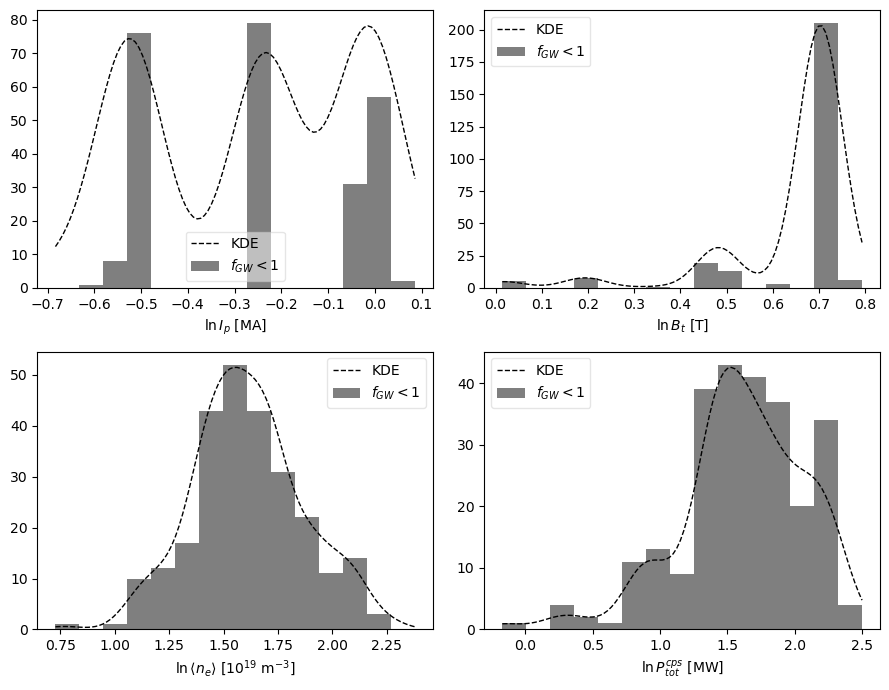

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(9, 7))
dist_labels = [r'$\ln I_p$ [MA]', r'$\ln B_t$ [T]',
               r'$\ln\langle n_e\rangle$ [$10^{19}$ m$^{-3}$]', r'$\ln P_{tot}^{cps}$ [MW]']
for var, label, ax in zip(FREE_REGRESSORS, dist_labels, axes.ravel()):
    plotting.plot_param_dist(fit_df, var, 15, label, overlay_kde=True, ax=ax)
fig.tight_layout()
fig.savefig(FIG_DIR / 'param_distributions.pdf', dpi=300, bbox_inches='tight')

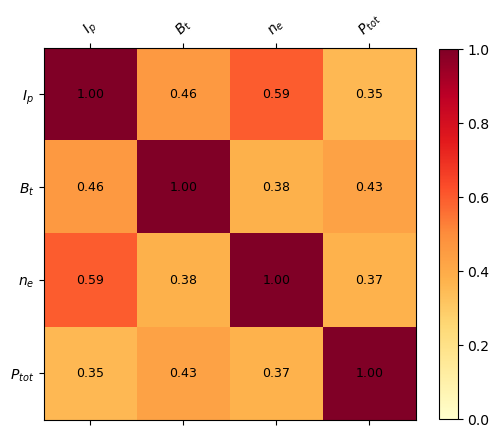

In [5]:
plotting.plot_correlation_matrix(
    fit_df, FREE_REGRESSORS, [r'$I_p$', r'$B_t$', r'$n_e$', r'$P_{tot}$'],
    save_path=FIG_DIR / 'corr_matrix.pdf');

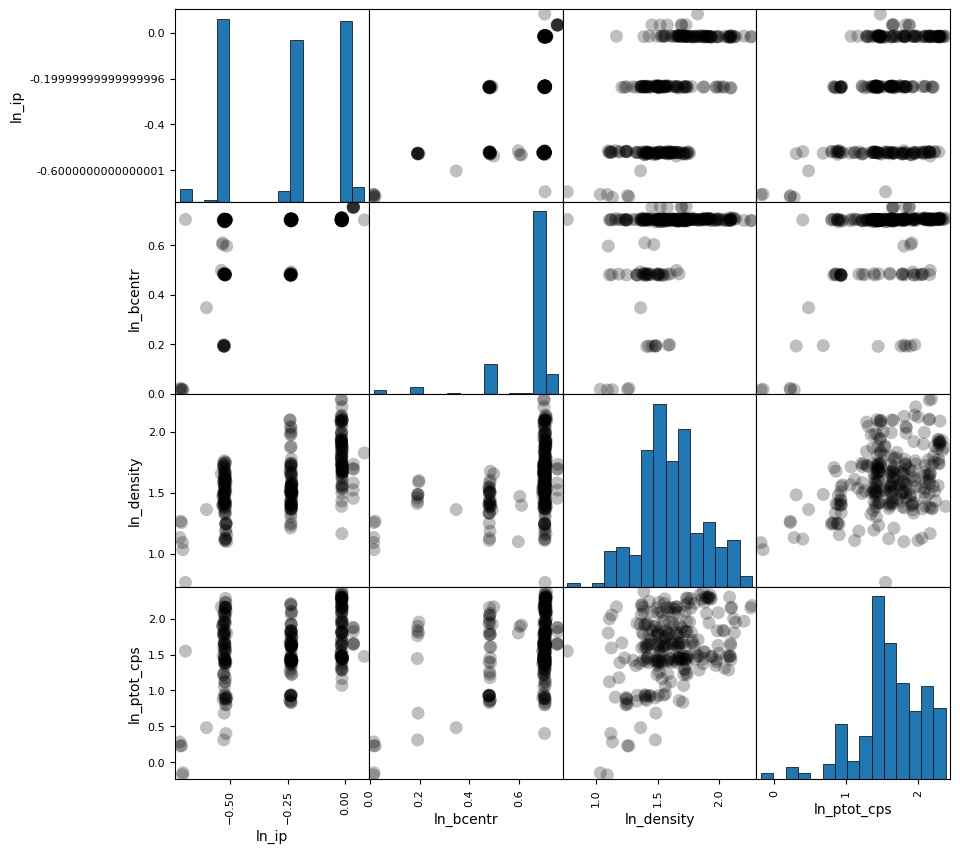

In [6]:
plotting.plot_scatter_matrix(fit_df, FREE_REGRESSORS, bins=15, s=350,
                             save_path=FIG_DIR / 'scatter_matrix.pdf');

## 4. KDE-weighted fit (headline)

`fit_power_law` fits the log-linear model with `curve_fit`, giving each point
$\sigma = \sqrt{\,\mathrm{pdf}/\mathrm{pdf}_{max}}$ from a Gaussian KDE (Scott
bandwidth), so the least-squares weight is $\propto 1/\mathrm{pdf}$. The KDE
is built on the four free regressors only (the frozen-geometry columns add
dimensions without sampling information), the density is floored at its 5th
percentile (bounding the leverage of isolated points), and the effective
sample size $(\sum w)^2/\sum w^2$ is reported.
Held-out $f_{GW} > 1$ phases are overlaid in red.

ln_tauth_ptot ~ KDE power-law fit (260 points, effective N = 156; KDE over 4 vars)
  a_ln_ip: 1.06 +/- 0.06
  a_ln_bcentr: 0.04 +/- 0.06
  a_ln_density: 0.54 +/- 0.04
  a_ln_ptot_cps: -0.92 +/- 0.02
  a_ln_rsurf: 1.97 (fixed)
  a_ln_kappa_a: 0.78 (fixed)
  a_ln_eps: 0.58 (fixed)
  C: 8.34e-02 +/- 7.29e-03
  R^2: 0.874


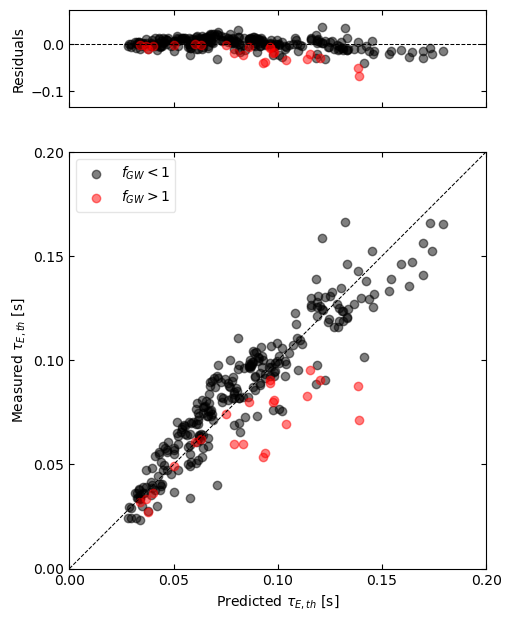

In [7]:
fit_kde = fit_power_law(
    fit_df, TARGET, ENGINEERING_REGRESSORS,
    fixed_exponents=FIXED_GEOMETRY_EXPONENTS,
    isotope_exponent=ISOTOPE_EXPONENT_THERMAL, weighting='kde')

plotting.plot_scaling(fit_kde, axis_labels=TAU_LABELS, upper_bd=0.20,
                      extra=fit_kde.predict(fgw_df),
                      save_path=FIG_DIR / 'kde_tauth.pdf');

## 5. OLS fit (weighting sensitivity)

The same model without weighting. Differences from section 4 measure how
much the exponents depend on the sampling of the database rather than on
the physics.

ln_tauth_ptot ~ OLS power-law fit (260 points)
  a_ln_ip: 1.00 +/- 0.05
  a_ln_bcentr: 0.22 +/- 0.08
  a_ln_density: 0.43 +/- 0.05
  a_ln_ptot_cps: -0.88 +/- 0.02
  a_ln_rsurf: 1.97 (fixed)
  a_ln_kappa_a: 0.78 (fixed)
  a_ln_eps: 0.58 (fixed)
  C: 8.47e-02 +/- 7.73e-03
  R^2: 0.887


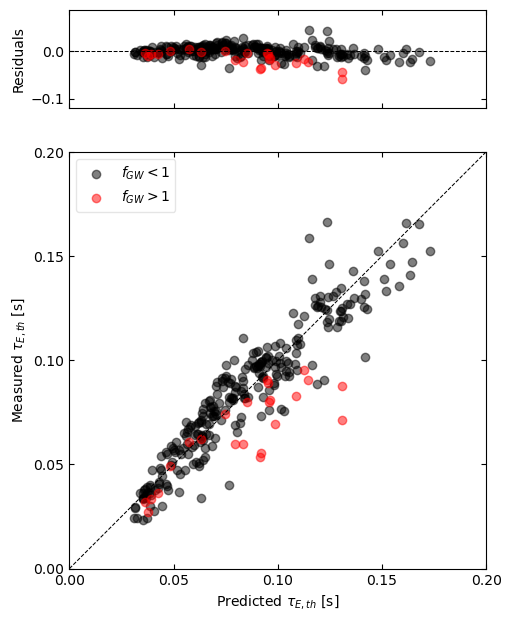

In [8]:
fit_ols = fit_power_law(
    fit_df, TARGET, ENGINEERING_REGRESSORS,
    fixed_exponents=FIXED_GEOMETRY_EXPONENTS,
    isotope_exponent=ISOTOPE_EXPONENT_THERMAL, weighting='ols')

plotting.plot_scaling(fit_ols, axis_labels=TAU_LABELS, upper_bd=0.20,
                      extra=fit_ols.predict(fgw_df),
                      save_path=FIG_DIR / 'ols_tauth.pdf');

## 6. Bootstrap exponent distributions

The single-fit error bars understate the real uncertainty, which is
dominated by which operating points happen to be in the database. Each
bootstrap refits the KDE-weighted model on a random 75% or 50% subset, 1000
times; the exponent histograms are the uncertainty estimate. Dashed lines:
IPB98(y,2) exponents.

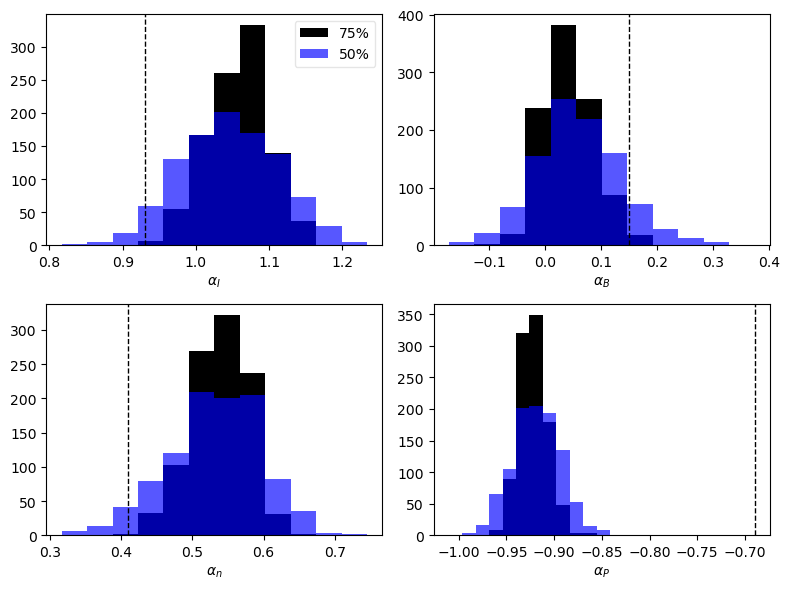

In [9]:
rng = np.random.default_rng(SEED)

boots = {f'{f:.0%}': subset_bootstrap(
        fit_df, TARGET, ENGINEERING_REGRESSORS,
        fixed_exponents=FIXED_GEOMETRY_EXPONENTS,
        isotope_exponent=ISOTOPE_EXPONENT_THERMAL,
        frac=f, num_repeats=N_REPEATS, weighting='kde', rng=rng)
    for f in FRACS}

H98_REF = [IPB98Y2.exponents[k] for k in ('ip', 'bcentr', 'density', 'ptot_cps')]
plotting.plot_exponent_histograms(
    boots, FREE_REGRESSORS, EXPONENT_LABELS, reference=H98_REF,
    save_path=FIG_DIR / 'bootstrap_exponents.pdf');

75% subsets — mean: [ 1.06  0.04  0.54 -0.92]   2 sigma: [0.08 0.09 0.08 0.03]   (retries: 0)
50% subsets — mean: [ 1.05  0.06  0.53 -0.92]   2 sigma: [0.13 0.15 0.13 0.05]   (retries: 0)


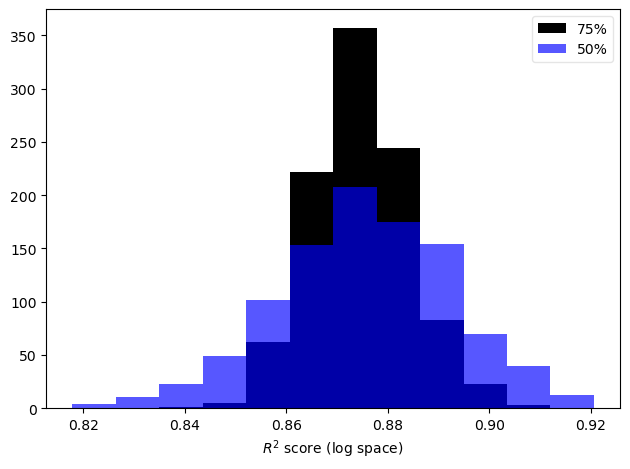

In [10]:
for label, boot in boots.items():
    means = np.array([boot.exponent_samples[k].mean() for k in FREE_REGRESSORS])
    two_sigma = 2 * np.array([boot.exponent_samples[k].std() for k in FREE_REGRESSORS])
    print(f'{label} subsets — mean: {np.round(means, 2)}   2 sigma: {np.round(two_sigma, 2)}'
          f'   (retries: {boot.n_retries})')

plotting.plot_histograms({k: b.r2_samples for k, b in boots.items()},
                         r'$R^2$ score (log space)',
                         save_path=FIG_DIR / 'bootstrap_r2.pdf');

## 7. Summary

Free exponents from the headline KDE fit ($\pm 1\sigma$ from the fit
covariance), the OLS fit, and the 50%-subset bootstrap ($\pm 2\sigma$), next
to IPB98(y,2).

In [11]:
rows = []
for name, plain in zip(FREE_REGRESSORS, ('ip', 'bcentr', 'density', 'ptot_cps')):
    b50 = boots['50%'].exponent_samples[name]
    rows.append({
        'exponent': f'alpha_{plain}',
        'KDE fit (±1σ)': f'{fit_kde.exponents[name]:.2f} ± {fit_kde.stdevs[name]:.2f}',
        'OLS fit (±1σ)': f'{fit_ols.exponents[name]:.2f} ± {fit_ols.stdevs[name]:.2f}',
        'bootstrap 50% (±2σ)': f'{b50.mean():.2f} ± {2 * b50.std():.2f}',
        'IPB98(y,2)': IPB98Y2.exponents[plain],
    })
summary = pd.DataFrame(rows).set_index('exponent')

print(f'R^2 (log space): KDE {fit_kde.r2:.3f} | OLS {fit_ols.r2:.3f}')
print(f'Effective N (KDE): {fit_kde.ess:.0f} of {len(fit_kde.y)} points')
summary

R^2 (log space): KDE 0.874 | OLS 0.887
Effective N (KDE): 156 of 260 points


,KDE fit (±1σ),OLS fit (±1σ),bootstrap 50% (±2σ),"IPB98(y,2)"
exponent,,,,
alpha_ip,1.06 ± 0.06,1.00 ± 0.05,1.05 ± 0.13,0.93
alpha_bcentr,0.04 ± 0.06,0.22 ± 0.08,0.06 ± 0.15,0.15
alpha_density,0.54 ± 0.04,0.43 ± 0.05,0.53 ± 0.13,0.41
alpha_ptot_cps,-0.92 ± 0.02,-0.88 ± 0.02,-0.92 ± 0.05,-0.69
